# Pipeline

In [1]:
# Loads relational tables into DuckDB, prepares data with SQL, and runs EDA

import duckdb
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Loading relational tables into DuckDB
con = duckdb.connect()
con.execute("CREATE TABLE transactions AS SELECT * FROM read_csv_auto('../data/relational/transactions.csv')")
con.execute("CREATE TABLE transaction_types AS SELECT * FROM read_csv_auto('../data/relational/transaction_types.csv')")
con.execute("CREATE TABLE time_steps AS SELECT * FROM read_csv_auto('../data/relational/time_steps.csv')")
con.execute("CREATE TABLE accounts AS SELECT * FROM read_csv_auto('../data/relational/accounts.csv')")

# SQL query to prepare data for modeling
df = con.execute("""
    SELECT
      t.amount,
      t.isFraud,
      tt.type_name,
      ts.hour_of_day,
      ts.day_of_month,
      COALESCE(CASE WHEN a.account_type = 'merchant' THEN 1 ELSE 0 END, 0) AS is_merchant
FROM transactions t
JOIN transaction_types tt ON t.type_id = tt.type_id
JOIN time_steps ts ON t.step = ts.step
LEFT JOIN accounts a ON t.recipient_id = a.account_id
""").df()

# Performing brief EDA

print(df.shape)
print(df.isnull().sum())
print(df['isFraud'].value_counts())

(6362620, 6)
amount          0
isFraud         0
type_name       0
hour_of_day     0
day_of_month    0
is_merchant     0
dtype: int64
isFraud
0    6354407
1       8213
Name: count, dtype: int64


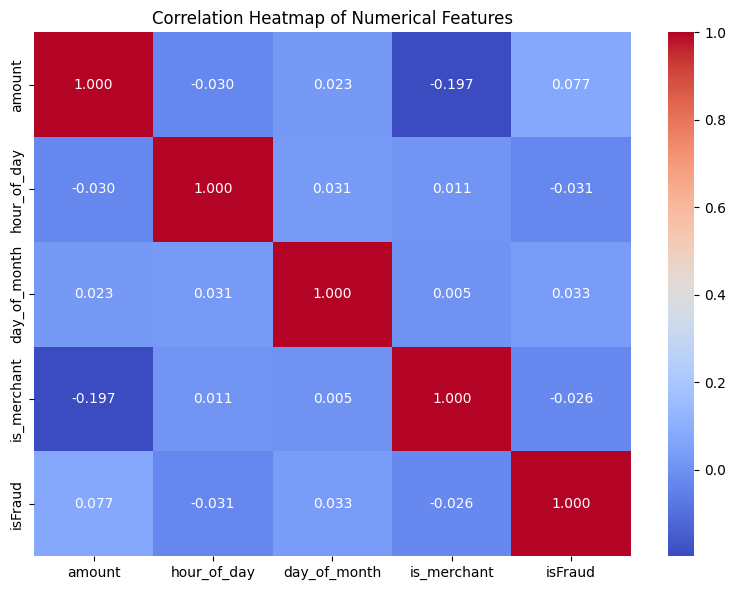

In [2]:
# Correlation heatmap of numerical features
corr = df[['amount', 'hour_of_day', 'day_of_month', 'is_merchant', 'isFraud']].corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr, annot=True, fmt='.3f', cmap='coolwarm', ax=ax)
ax.set_title('Correlation Heatmap of Numerical Features')
plt.tight_layout()
plt.show()

In [3]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import recall_score, f1_score, precision_score, confusion_matrix

# Preparing features

df = pd.get_dummies(df, columns = ['type_name']) # Converting categorical columns to numeric
X = df.drop(columns = ['isFraud']) # Defining predictor variables
y = df['isFraud'] # Defining target variable

# Splitting the data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size = 0.2, random_state = 42)

model = make_pipeline(StandardScaler(), LogisticRegression(class_weight = 'balanced', max_iter = 10000)) # Instantiating the model

model.fit(X_train, y_train) # Fitting the model

y_pred = model.predict(X_test) # Making predictions

# Evaluating
recall = recall_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

print(f"Recall: {recall}")
print(f"Precision: {precision}")
print(f"f1: {f1}")
print(f"Confusion Matrix: {cm}")

Recall: 0.8754512635379061
Precision: 0.006328921212543009
f1: 0.012566991565864423
Confusion Matrix: [[1042420  228442]
 [    207    1455]]
